In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('../..'))
from notebook_setup import *

## Ce notebook expose la méthodologie employée pour l’agrégation et la structuration des données portant sur les impayés.


### Méthode d’agrégation de la base *impayés*

L’objectif est de regrouper les informations **par client** afin d’obtenir une vue synthétique de la situation des impayés.  
Les indicateurs retenus sont les suivants :

- **Nombre total d’actions d’impayé** : comptage du nombre d’événements enregistrés pour chaque client.

- **Montant total impayé** : somme des montants de cotisations impayées associés aux différentes actions.

- **Types d’actions** : création de compteurs pour chaque type d’action rencontré  
  (`1er Impayé`, `1ere lettre de relance`, `Mise en demeure`, `2ème Impayé`,  
  `Suspension de garanties`, `Annonce du contentieux`, `En recouvrement`, etc.).

- **Durée maximale d’une action** : calcul du nombre de jours entre la date de début et la date de fin, puis sélection de la durée la plus longue pour chaque client.

- **Suppression des variables inutiles** : la variable `impaye_numero_dossier`, qui n’apporte pas d’information pertinente au niveau agrégé, est exclue de l’analyse.

La fonction d’agrégation produit ainsi un tableau final `df_impayes_agg`, où chaque ligne représente un client et chaque colonne un indicateur synthétique permettant de caractériser son profil d’impayés.


In [2]:
                            ###  FONCTION FINALE ###
                            ########################

def aggregate_impayes(df_impayes):
    """
    Agrège les données d'impayés au niveau client :
    - impaye_nb_actions
    - impaye_montant_total
    - compteurs pour chaque type d'action (impaye_action_...)
    - impaye_impaye_duree_max_action_jours
    """

    df = df_impayes.copy()

    # Dates en datetime
    df["impaye_date_debut_action"] = pd.to_datetime(df["impaye_date_debut_action"])
    df["impaye_date_fin_action"] = pd.to_datetime(df["impaye_date_fin_action"])

    # Durée de l'action
    df["impaye_duree_action_jours"] = (
        df["impaye_date_fin_action"] - df["impaye_date_debut_action"]
    ).dt.days

    # 1) Nombre total d'actions
    nb_actions = (
        df.groupby("client_code")
          .size()
          .to_frame("impaye_nb_actions")
    )

    # 2) Montant total
    montant_total = (
        df.groupby("client_code")["impaye_montant_cotisation_impayee"]
          .sum()
          .to_frame("impaye_montant_total")
    )

    # 3) Compteurs des types d’action (pivot)
    df_types = (
        df.groupby(["client_code", "impaye_type_action"])
          .size()
          .unstack(fill_value=0)
    )

    # Mapping des noms propres
    mapping_actions = {
        "1er Impayé": "impaye_action_1er_impaye",
        "1ere lettre de relance": "impaye_action_1ere_lettre_relance",
        "Mise en demeure": "impaye_action_mise_en_demeure",
        "2ème Impayé": "impaye_action_2eme_impaye",
        "Suspension de garanties": "impaye_action_suspension_garanties",
        "Annonce du contentieux": "impaye_action_annonce_contentieux",
        "En recouvrement": "impaye_action_en_recouvrement"
    }

    # Renommage
    df_types = df_types.rename(columns=mapping_actions)

    # Si d'autres types existent → renommer proprement
    df_types = df_types.rename(columns=lambda x: "nb_" + x.lower()
                                                 .replace(" ", "_")
                                                 .replace("é", "e")
                                                 .replace("è", "e")
                                                 .replace("ê", "e")
                                                 .replace("à", "a")
                                                 if x not in mapping_actions else x)

    # 4) Durée maximale
    duree_max = (
        df.groupby("client_code")["impaye_duree_action_jours"]
          .max()
          .to_frame("impaye_duree_max_action_jours")
    )

    # Assemblage final
    df_impayes_agg = (
        nb_actions
        .join(montant_total, how="left")
        .join(df_types, how="left")
        .join(duree_max, how="left")
        .reset_index()
    )

    return df_impayes_agg


In [3]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_processing.data_load import data_loading

In [4]:
#Data loading
consommations, impayes, interactions, portefeuille, reclamations = data_loading("training")
df_impayes = impayes
df_impayes.head()

c:\Users\kelly\BDC-Alptis\src\data_processing\data_load.py:19: DtypeWarning: Columns (0: client_nps_date_reponse_n_moins1, 1: client_nps_verbatim_n_moins1) have mixed types. Specify dtype option on import or set low_memory=False.
  data_frames[key] = pd.read_csv(filepath, sep=";")


,client_code,impaye_numero_dossier,impaye_type_action,impaye_date_debut_action,impaye_date_fin_action,impaye_montant_cotisation_impayee
0,14754048,2107721222,Mise en demeure,2023-02-03,2023-02-09,250.95
1,14754048,2107721222,2ème Impayé,2023-01-19,2023-02-02,235.95
2,14563067,2080438223,Annonce du contentieux,2022-12-09,2023-01-03,140.00
3,14563067,2080438223,Suspension de garanties,2022-12-02,2022-12-08,140.00
4,12629114,1804159223,Annonce du contentieux,2022-12-09,2023-02-06,254.04


In [5]:
df_impayes.shape

(15587, 6)

15587 de dossiers d'impayés sur la période 

In [6]:
freq_impayes = df_impayes.groupby('client_code').size()
freq_impayes.describe()

count    7167.000000
mean        2.174829
std         1.768721
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max        14.000000
dtype: float64

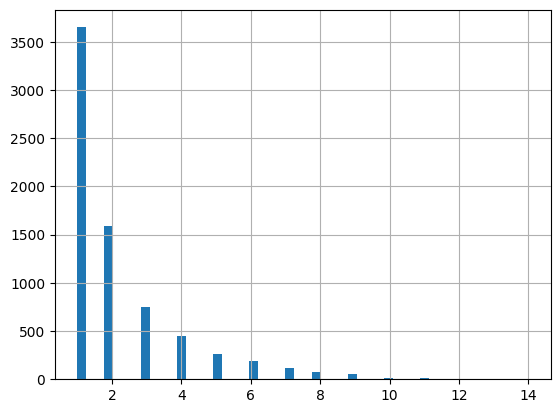

In [7]:
freq_impayes.hist(bins=50)
plt.show()

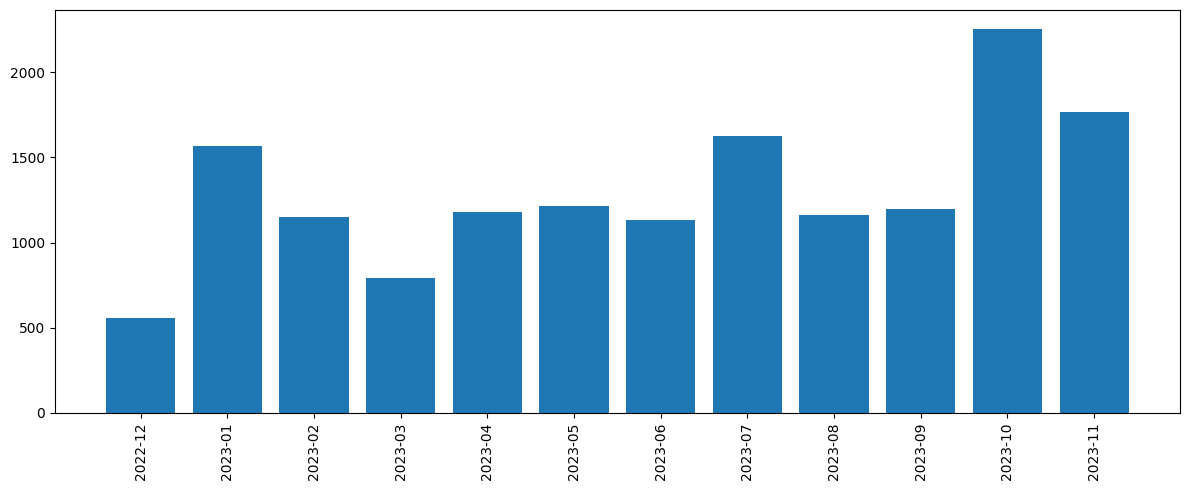

impaye_date_debut_action,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11
0,555,1565,1149,791,1182,1212,1132,1627,1159,1196,2254,1765


In [8]:
df_impayes['impaye_date_debut_action'] = pd.to_datetime(df_impayes['impaye_date_debut_action'])

freq_par_mois = df_impayes.groupby(df_impayes['impaye_date_debut_action'].dt.to_period('M')).size()
freq_par_mois = pd.DataFrame(freq_par_mois).T
freq_par_mois.columns = freq_par_mois.columns.astype(str)

freq_par_mois_T = freq_par_mois.T

plt.figure(figsize=(12, 5))
plt.bar(freq_par_mois_T.index, freq_par_mois_T[0])
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

freq_par_mois

In [9]:
df_impayes['impaye_type_action'].value_counts(normalize=True) * 100

impaye_type_action
1er Impayé                 43.876307
1ere lettre de relance     22.005517
Mise en demeure            19.355873
2ème Impayé                 7.538333
Suspension de garanties     3.971258
Annonce du contentieux      2.617566
En recouvrement             0.635145
Name: proportion, dtype: float64

In [10]:
def aggregate_impayes(df_impayes):
    """
    Agrège les données d'impayés au niveau client :
    - impaye_nb_actions
    - impaye_montant_total
    - compteurs pour chaque type d'action
    - impaye_duree_max_action_jours
    """

    df = df_impayes.copy()

    # Dates en datetime
    df["impaye_date_debut_action"] = pd.to_datetime(df["impaye_date_debut_action"])
    df["impaye_date_fin_action"] = pd.to_datetime(df["impaye_date_fin_action"])

    # Durée de l'action
    df["impaye_duree_action_jours"] = (
        df["impaye_date_fin_action"] - df["impaye_date_debut_action"]
    ).dt.days

    # 1) Nombre total d'actions
    nb_actions = (
        df.groupby("client_code")
          .size()
          .to_frame("impaye_nb_actions")
    )

    # 2) Montant total
    montant_total = (
        df.groupby("client_code")["impaye_montant_cotisation_impayee"]
          .sum()
          .to_frame("impaye_montant_total")
    )

    # 3) Compteurs des types d’action (pivot)
    df_types = (
        df.groupby(["client_code", "impaye_type_action"])
          .size()
          .unstack(fill_value=0)
    )

    # Mapping des noms propres
    mapping_actions = {
        "1er Impayé": "impaye_action_1er_impaye",
        "1ere lettre de relance": "impaye_action_1ere_lettre_relance",
        "Mise en demeure": "impaye_action_mise_en_demeure",
        "2ème Impayé": "impaye_action_2eme_impaye",
        "Suspension de garanties": "impaye_action_suspension_garanties",
        "Annonce du contentieux": "impaye_action_annonce_contentieux",
        "En recouvrement": "impaye_action_en_recouvrement"
    }

    # Renommage
    df_types = df_types.rename(columns=mapping_actions)

    # Si d'autres types existent → renommer proprement
    df_types = df_types.rename(columns=lambda x: "nb_" + x.lower()
                                                 .replace(" ", "_")
                                                 .replace("é", "e")
                                                 .replace("è", "e")
                                                 .replace("ê", "e")
                                                 .replace("à", "a")
                                                 if x not in mapping_actions else x)

    # 4) Durée maximale
    duree_max = (
        df.groupby("client_code")["impaye_duree_action_jours"]
          .max()
          .to_frame("impaye_duree_max_action_jours")
    )

    # Assemblage final
    df_impayes_agg = (
        nb_actions
        .join(montant_total, how="left")
        .join(df_types, how="left")
        .join(duree_max, how="left")
        .reset_index()
    )

    return df_impayes_agg


In [11]:
df_impayes_agg = aggregate_impayes(df_impayes)
df_impayes_agg.head()

,client_code,impaye_nb_actions,impaye_montant_total,nb_impaye_action_1er_impaye,nb_impaye_action_1ere_lettre_relance,nb_impaye_action_2eme_impaye,nb_impaye_action_annonce_contentieux,nb_impaye_action_en_recouvrement,nb_impaye_action_mise_en_demeure,nb_impaye_action_suspension_garanties,impaye_duree_max_action_jours
0,31396,1,1447.32,0,1,0,0,0,0,0,10.0
1,32628,1,1143.84,0,1,0,0,0,0,0,10.0
2,37262,1,544.53,0,1,0,0,0,0,0,5.0
3,38872,2,2627.52,0,1,0,0,0,1,0,10.0
4,88047,4,1349.76,0,2,0,0,0,2,0,27.0
